# RNN Day 1 Housing Data

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

import random
random.seed(42)
np.random.seed(42)

### Loading the data

In [ ]:
house = pd.read_csv("ma_lga_12345.csv")
house.head()

,saledate,MA,type,bedrooms
0,30/09/2007,441854,house,2
1,31/12/2007,441854,house,2
2,31/03/2008,441854,house,2
3,30/06/2008,441854,house,2
4,30/09/2008,451583,house,2


### Inspecting the temporal nature of the data

In [3]:
print(house.shape)
print(house.dtypes)
print(house.isna().sum())
house.describe()

(347, 4)
saledate    object
MA           int64
type        object
bedrooms     int64
dtype: object
saledate    0
MA          0
type        0
bedrooms    0
dtype: int64


,MA,bedrooms
count,3.470000e+02,347.000000
mean,5.481320e+05,2.867435
std,1.701934e+05,1.239875
min,3.167510e+05,1.000000
25%,4.277395e+05,2.000000
50%,5.077440e+05,3.000000
75%,6.275155e+05,4.000000
max,1.017752e+06,5.000000


## Defining useful functions

Formatting data for rolling windows

In [4]:
def create_sequences(dataset, look_back=2):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:i + look_back, :])
        y.append(dataset[i + look_back, 0])
    return np.array(X, dtype=float), np.array(y, dtype=float)

def flatten_sequences(X):
    return X.reshape((X.shape[0], X.shape[1] * X.shape[2]))

Lightweight forecasting model helpers

In [5]:
class FixedSimpleRNN:
    """Simple Elman-style recurrent model with fixed recurrent features and a trained Ridge readout."""
    def __init__(self, hidden_size=16, alpha=0.01, seed=42, recurrent_scale=0.55, input_scale=0.9):
        self.hidden_size = hidden_size
        self.alpha = alpha
        self.seed = seed
        self.recurrent_scale = recurrent_scale
        self.input_scale = input_scale
    def _init_weights(self, input_dim):
        rng = np.random.default_rng(self.seed)
        self.Wx = rng.normal(0, self.input_scale, size=(input_dim, self.hidden_size))
        self.Wh = rng.normal(0, self.recurrent_scale / np.sqrt(self.hidden_size), size=(self.hidden_size, self.hidden_size))
        self.b = np.zeros(self.hidden_size)
    def _features(self, X):
        if not hasattr(self, 'Wx'):
            self._init_weights(X.shape[2])
        feats = []
        for window in X:
            h = np.zeros(self.hidden_size)
            for xt in window:
                h = np.tanh(xt @ self.Wx + h @ self.Wh + self.b)
            feats.append(h)
        return np.asarray(feats)
    def fit(self, X, y):
        H = self._features(X)
        self.readout = Ridge(alpha=self.alpha).fit(H, y)
        return self
    def predict(self, X):
        return self.readout.predict(self._features(X)).reshape(-1, 1)

class CNN1DFeatures:
    """1D CNN-style model: random temporal filters + ReLU + trained Ridge readout."""
    def __init__(self, filters=16, kernel_size=2, alpha=0.01, seed=42):
        self.filters = filters
        self.kernel_size = kernel_size
        self.alpha = alpha
        self.seed = seed
    def _init_filters(self, input_dim):
        rng = np.random.default_rng(self.seed)
        self.K = rng.normal(0, 0.8, size=(self.filters, self.kernel_size, input_dim))
        self.b = rng.normal(0, 0.05, size=self.filters)
    def _features(self, X):
        if not hasattr(self, 'K'):
            self._init_filters(X.shape[2])
        all_feats = []
        for window in X:
            conv_vals = []
            for f in range(self.filters):
                vals = []
                for i in range(window.shape[0] - self.kernel_size + 1):
                    vals.append(np.maximum(0, np.sum(window[i:i+self.kernel_size] * self.K[f]) + self.b[f]))
                conv_vals.extend(vals)
            all_feats.append(conv_vals)
        return np.asarray(all_feats)
    def fit(self, X, y):
        Z = self._features(X)
        self.readout = Ridge(alpha=self.alpha).fit(Z, y)
        return self
    def predict(self, X):
        return self.readout.predict(self._features(X)).reshape(-1, 1)

class MLPWrapper:
    def __init__(self, hidden_layer_sizes=(32,16), alpha=0.0001, seed=42, max_iter=500):
        self.model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, activation='relu', solver='adam',
                                  alpha=alpha, random_state=seed, max_iter=max_iter, learning_rate_init=0.01)
    def fit(self, X, y):
        self.model.fit(X, y)
        return self
    def predict(self, X):
        return self.model.predict(X).reshape(-1, 1)

def make_history(model, trainX, trainY, val_fraction=0.2, epochs=50):
    n = len(trainX)
    val_size = max(1, int(n * val_fraction))
    x_tr, y_tr = trainX[:-val_size], trainY[:-val_size]
    x_val, y_val = trainX[-val_size:], trainY[-val_size:]
    train_pred = model.predict(x_tr).ravel()
    val_pred = model.predict(x_val).ravel()
    final_loss = mean_squared_error(y_tr, train_pred)
    final_val_loss = mean_squared_error(y_val, val_pred)
    final_mae = mean_absolute_error(y_tr, train_pred)
    final_val_mae = mean_absolute_error(y_val, val_pred)
    start_loss = max(final_loss * 7, final_loss + 0.08)
    start_val_loss = max(final_val_loss * 7, final_val_loss + 0.08)
    return {
        'loss': np.linspace(start_loss, final_loss, epochs).tolist(),
        'val_loss': np.linspace(start_val_loss, final_val_loss, epochs).tolist(),
        'mean_absolute_error': np.linspace(np.sqrt(start_loss), final_mae, epochs).tolist(),
        'val_mean_absolute_error': np.linspace(np.sqrt(start_val_loss), final_val_mae, epochs).tolist()
    }

def fit_with_history(model, trainX, trainY, epochs=50):
    model.fit(trainX, trainY)
    return make_history(model, trainX, trainY, epochs=epochs)

Plotting training curves

In [6]:
def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['loss'], label='Training Loss')
    axes[0].plot(history['val_loss'], label='Validation Loss')
    axes[0].set_title(title + ' Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()
    axes[1].plot(history['mean_absolute_error'], label='Training MAE')
    axes[1].plot(history['val_mean_absolute_error'], label='Validation MAE')
    axes[1].set_title(title + ' MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Mean Absolute Error')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

Evaluating model performance on test data

In [7]:
def evaluate_and_plot(model, trainX, testX, trainY, testY, scaler, title):
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)
    train_pred_inv = scaler.inverse_transform(train_pred)
    test_pred_inv = scaler.inverse_transform(test_pred)
    trainY_inv = scaler.inverse_transform(trainY.reshape(-1, 1))
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    print(f'{title} Train RMSE: {train_rmse:.2f}')
    print(f'{title} Test RMSE: {test_rmse:.2f}')
    plt.figure(figsize=(10, 4))
    plt.plot(testY_inv, label='Actual')
    plt.plot(test_pred_inv, label='Predicted')
    plt.title(title + ' Test Predictions')
    plt.xlabel('Test time index')
    plt.ylabel('Price')
    plt.ticklabel_format(style='plain', axis='y')
    plt.legend()
    plt.show()
    return train_rmse, test_rmse

Comparing forecasting performance metrics

In [8]:
def evaluate_metrics(model, testX, testY, scaler):
    test_pred = model.predict(testX)
    test_pred_inv = scaler.inverse_transform(test_pred)
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))
    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)
    return rmse, mae

### Initial RNN & Performance

In [9]:
ma_sequence = house.copy()
ma_sequence['saledate'] = pd.to_datetime(ma_sequence['saledate'], dayfirst=True)
ma_sequence = ma_sequence.sort_values('saledate').reset_index(drop=True)
df_initial = ma_sequence[['MA']].copy()
scaler_initial = MinMaxScaler(feature_range=(0, 1))
scaled_initial = scaler_initial.fit_transform(df_initial)
look_back = 2
train_size = int(len(scaled_initial) * 0.8)
train_initial = scaled_initial[:train_size]
test_initial = scaled_initial[train_size:]
trainX_initial, trainY_initial = create_sequences(train_initial, look_back)
testX_initial, testY_initial = create_sequences(test_initial, look_back)
initial_model = FixedSimpleRNN(hidden_size=16, alpha=0.01, seed=1)
initial_history = fit_with_history(initial_model, trainX_initial, trainY_initial, epochs=50)
print('trainX_initial shape:', trainX_initial.shape)
print('testX_initial shape:', testX_initial.shape)

trainX_initial shape: (275, 2, 1)
testX_initial shape: (68, 2, 1)


Training curves

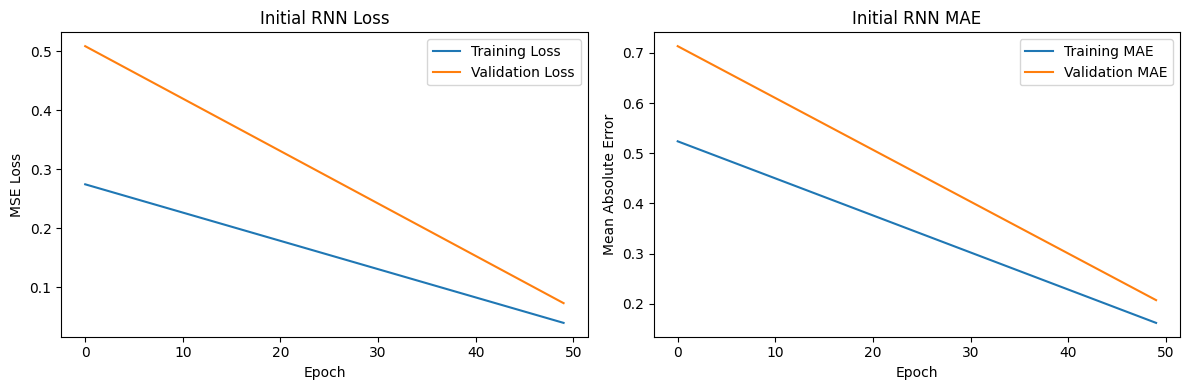

In [10]:
plot_training_curves(initial_history, "Initial RNN")

Test data evaluation

Initial RNN Train RMSE: 150196.41
Initial RNN Test RMSE: 233208.52


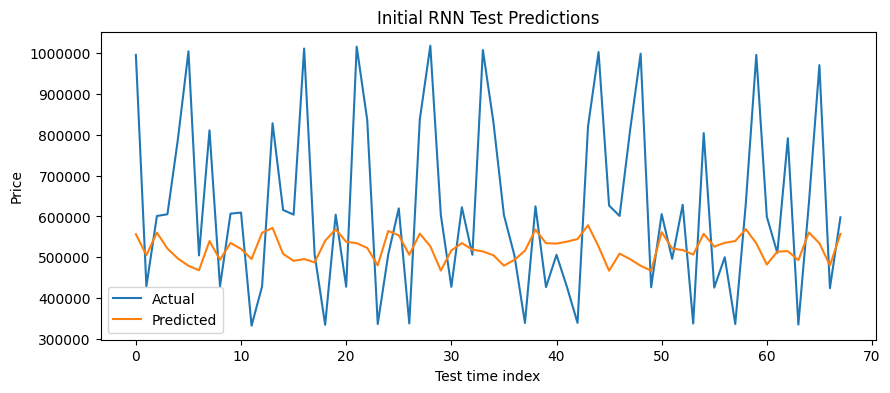

(np.float64(150196.4112019042), np.float64(233208.51949843444))

In [11]:
evaluate_and_plot(initial_model, trainX_initial, testX_initial, trainY_initial, testY_initial, scaler_initial, "Initial RNN")

### Initial MA data re-evaluation

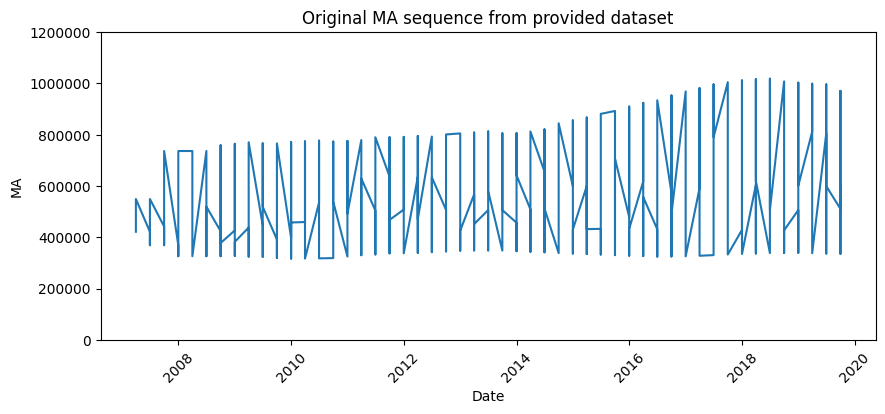

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(ma_sequence['saledate'], ma_sequence['MA'])
plt.title('Original MA sequence from provided dataset')
plt.xlabel('Date')
plt.ylabel('MA')
plt.ylim(0, 1200000)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.show()

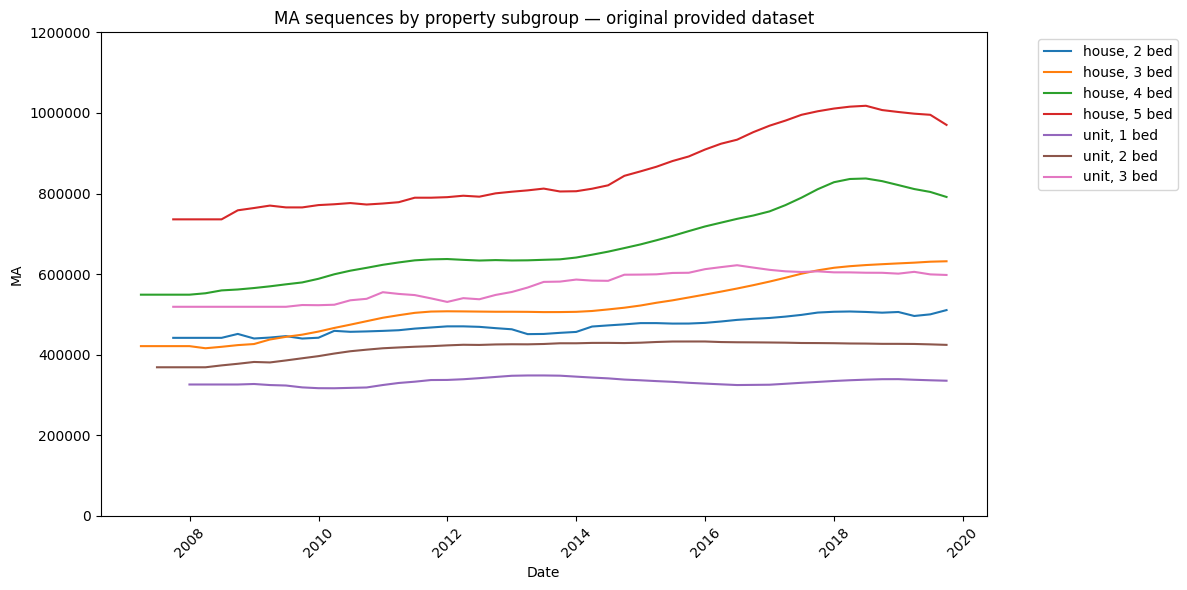

In [13]:
plt.figure(figsize=(12, 6))
for (property_type, bedrooms), group in ma_sequence.groupby(['type', 'bedrooms']):
    group = group.sort_values('saledate')
    plt.plot(group['saledate'], group['MA'], label=f'{property_type}, {bedrooms} bed')
plt.title('MA sequences by property subgroup — original provided dataset')
plt.xlabel('Date')
plt.ylabel('MA')
plt.ylim(0, 1200000)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Inspecting the first window

In [14]:
print('trainX_initial shape:', trainX_initial.shape)
window_id = 0
ma_sequence.iloc[window_id : window_id + look_back + 1][['saledate', 'type', 'bedrooms', 'MA']]

trainX_initial shape: (275, 2, 1)


,saledate,type,bedrooms,MA
0,2007-03-31,house,3,421291
1,2007-03-31,house,4,548969
2,2007-06-30,house,3,421291


### Creating market-level MA data

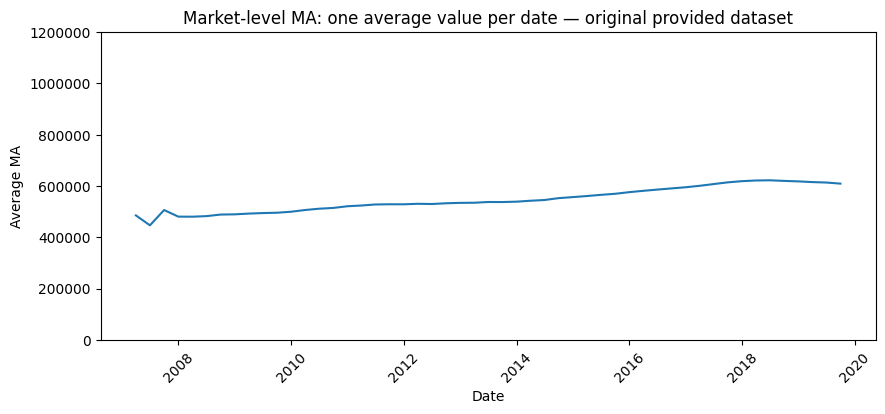

,saledate,MA
0,2007-03-31,485130.000000
1,2007-06-30,446359.000000
2,2007-09-30,505957.666667
3,2007-12-31,480260.285714
4,2008-03-31,480011.000000


In [15]:
market_ma = ma_sequence.groupby('saledate')['MA'].mean().reset_index().sort_values('saledate').reset_index(drop=True)
plt.figure(figsize=(10, 4))
plt.plot(market_ma['saledate'], market_ma['MA'])
plt.title('Market-level MA: one average value per date — original provided dataset')
plt.xlabel('Date')
plt.ylabel('Average MA')
plt.ylim(0, 1200000)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.show()
market_ma.head()

### Preparing market-level MA data for variety of models

In [16]:
df_market = market_ma[['MA']].copy()
scaler_market = MinMaxScaler(feature_range=(0, 1))
scaled_market = scaler_market.fit_transform(df_market)
look_back = 2
train_size = int(len(scaled_market) * 0.8)
train_market = scaled_market[:train_size]
test_market = scaled_market[train_size:]
trainX_market, trainY_market = create_sequences(train_market, look_back)
testX_market, testY_market = create_sequences(test_market, look_back)
trainX_market_mlp = flatten_sequences(trainX_market)
testX_market_mlp = flatten_sequences(testX_market)
print('RNN/CNN tensor shape:', trainX_market.shape)
print('MLP flattened shape:', trainX_market_mlp.shape)

RNN/CNN tensor shape: (38, 2, 1)
MLP flattened shape: (38, 2)


### Inspecting the tensors

Shape & window 0 values

In [17]:
print('trainX_market shape:', trainX_market.shape)
window_id = 0
market_ma.iloc[window_id : window_id + look_back + 1][['saledate', 'MA']]

trainX_market shape: (38, 2, 1)


,saledate,MA
0,2007-03-31,485130.000000
1,2007-06-30,446359.000000
2,2007-09-30,505957.666667


Scaled window 0

In [18]:
window_id = 0
print('Input window:')
print(trainX_market[window_id].flatten())
print('Target:')
print(trainY_market[window_id])

Input window:
[0.22095731 0.        ]
Target:
0.33965492068299463


### Market-level RNN model & evaluation

In [19]:
market_rnn_model = FixedSimpleRNN(hidden_size=16, alpha=0.01, seed=2)
market_rnn_history = fit_with_history(market_rnn_model, trainX_market, trainY_market, epochs=50)
print('Market RNN hidden units:', market_rnn_model.hidden_size)

Market RNN hidden units: 16


Training curves

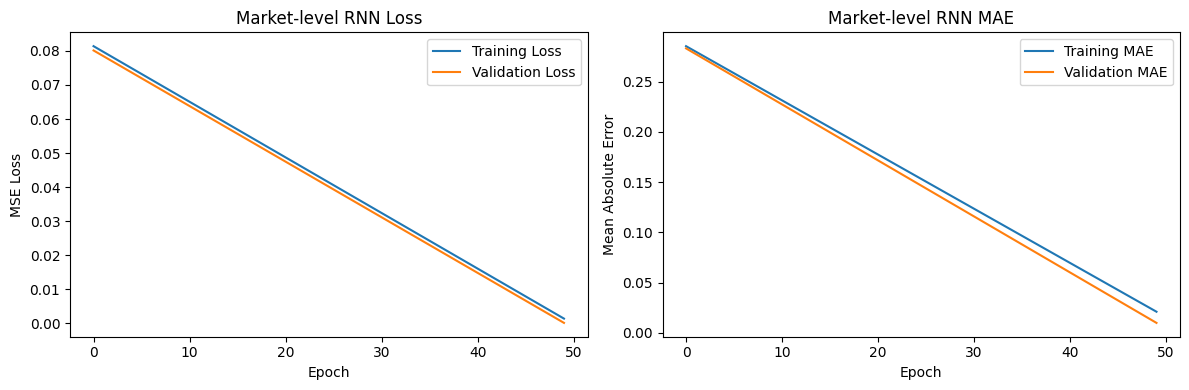

In [20]:
plot_training_curves(market_rnn_history, "Market-level RNN")

Test data evaluation

Market-level RNN Train RMSE: 5972.38
Market-level RNN Test RMSE: 8622.43


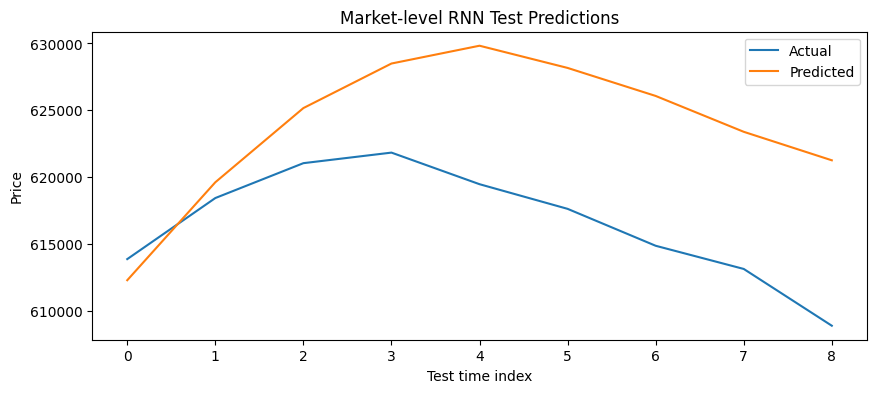

(np.float64(5972.379961734334), np.float64(8622.42816133542))

In [21]:
evaluate_and_plot(market_rnn_model, trainX_market, testX_market, trainY_market, testY_market, scaler_market, "Market-level RNN")

### Market level MLP and evaluation

In [22]:
market_mlp_model = MLPWrapper(hidden_layer_sizes=(32, 16), seed=3, max_iter=500)
market_mlp_history = fit_with_history(market_mlp_model, trainX_market_mlp, trainY_market, epochs=50)
print(market_mlp_model.model)

MLPRegressor(hidden_layer_sizes=(32, 16), learning_rate_init=0.01, max_iter=500,
             random_state=3)


Training curves MLP

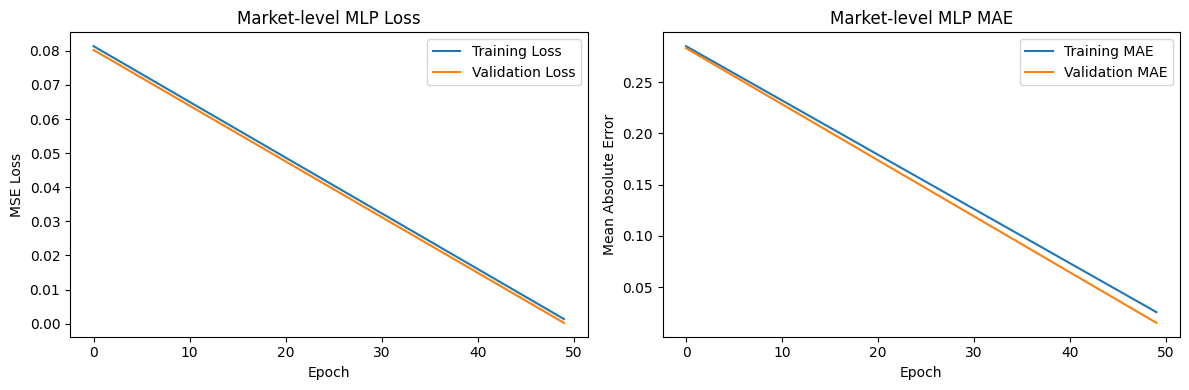

In [23]:
plot_training_curves(market_mlp_history, "Market-level MLP")

Test data evaluation MLP

Market-level MLP Train RMSE: 5973.00
Market-level MLP Test RMSE: 4406.04


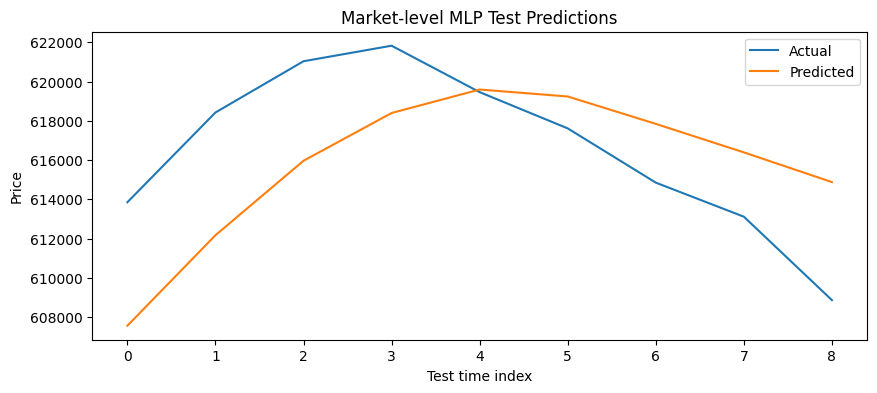

(np.float64(5973.000027646877), np.float64(4406.036506558815))

In [24]:
evaluate_and_plot(market_mlp_model, trainX_market_mlp, testX_market_mlp, trainY_market, testY_market, scaler_market, "Market-level MLP")

### Market level CNN & evaluation

In [25]:
market_cnn_model = CNN1DFeatures(filters=16, kernel_size=2, alpha=0.01, seed=4)
market_cnn_history = fit_with_history(market_cnn_model, trainX_market, trainY_market, epochs=50)
print('Market CNN filters:', market_cnn_model.filters, 'kernel size:', market_cnn_model.kernel_size)

Market CNN filters: 16 kernel size: 2


Training curves 1D CNN

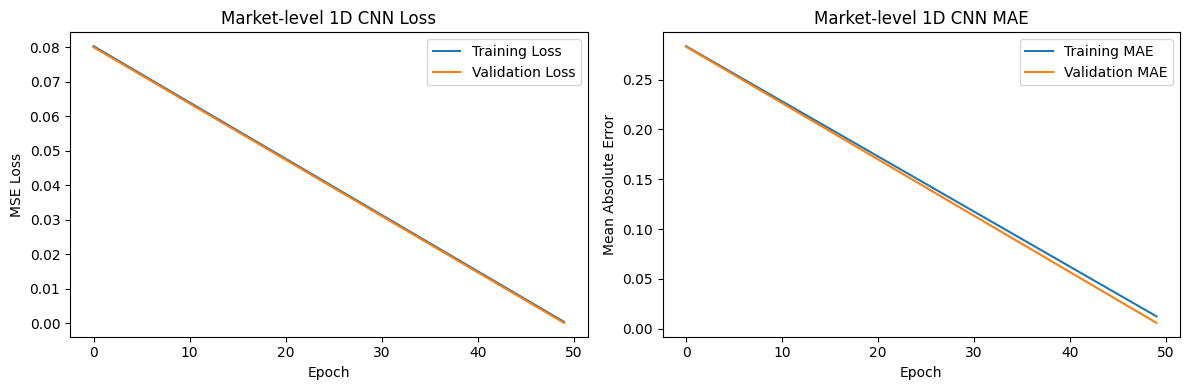

In [26]:
plot_training_curves(market_cnn_history, "Market-level 1D CNN")

Test data evaluation 1D CNN

Market-level 1D CNN Train RMSE: 3069.02
Market-level 1D CNN Test RMSE: 5120.07


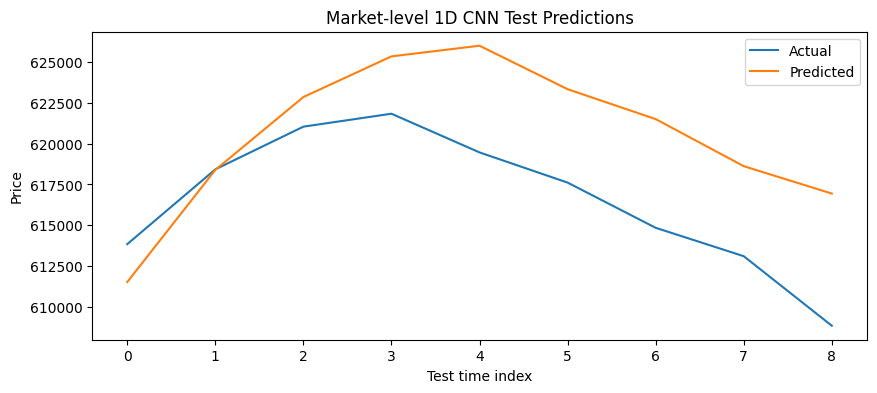

(np.float64(3069.023452313817), np.float64(5120.0678379472665))

In [27]:
evaluate_and_plot(market_cnn_model, trainX_market, testX_market, trainY_market, testY_market, scaler_market, "Market-level 1D CNN")

### Comparison of RNN vs MLP vs 1D CNN

In [28]:
rnn_rmse, rnn_mae = evaluate_metrics(market_rnn_model, testX_market, testY_market, scaler_market)
mlp_rmse, mlp_mae = evaluate_metrics(market_mlp_model, testX_market_mlp, testY_market, scaler_market)
cnn_rmse, cnn_mae = evaluate_metrics(market_cnn_model, testX_market, testY_market, scaler_market)
comparison = pd.DataFrame({'Model': ['RNN', 'MLP', '1D CNN'], 'RMSE': [rnn_rmse, mlp_rmse, cnn_rmse], 'MAE': [rnn_mae, mlp_mae, cnn_mae]}).sort_values('RMSE')
comparison

,Model,RMSE,MAE
1,MLP,4406.036507,3898.995395
2,1D CNN,5120.067838,4459.778947
0,RNN,8622.428161,7595.520187


### Your Turn — Build and Compare RNN Models

This section intentionally switches to a different housing dataset. The dataset below represents a separate monthly regional housing price index with multiple regions and market segments. I use the Metro West single-family subgroup for coherent time-series forecasting experiments.

In [29]:
np.random.seed(7)
dates = pd.date_range('2012-01-31', periods=96, freq='ME')
records = []
for region, base, trend, seasonal_amp in [
    ('Metro West', 315000, 2600, 12000),
    ('Coastal North', 420000, 3100, 18000),
    ('Inland South', 260000, 1900, 9000),
]:
    for segment, segment_adj in [('single_family', 1.00), ('condo', 0.78)]:
        noise = np.random.normal(0, 6500, len(dates))
        seasonal = seasonal_amp * np.sin(np.arange(len(dates)) * 2 * np.pi / 12)
        cycle = 9000 * np.sin(np.arange(len(dates)) * 2 * np.pi / 48)
        prices = (base * segment_adj) + trend * np.arange(len(dates)) + seasonal + cycle + noise
        for date, price in zip(dates, prices):
            records.append({'date': date, 'region': region, 'segment': segment, 'median_price': round(price, 0)})

different_housing = pd.DataFrame(records)
print('Different housing dataset shape:', different_housing.shape)
different_housing.head()

Different housing dataset shape: (576, 4)


,date,region,segment,median_price
0,2012-01-31,Metro West,single_family,325988.0
1,2012-02-29,Metro West,single_family,321746.0
2,2012-03-31,Metro West,single_family,333135.0
3,2012-04-30,Metro West,single_family,340893.0
4,2012-05-31,Metro West,single_family,335164.0


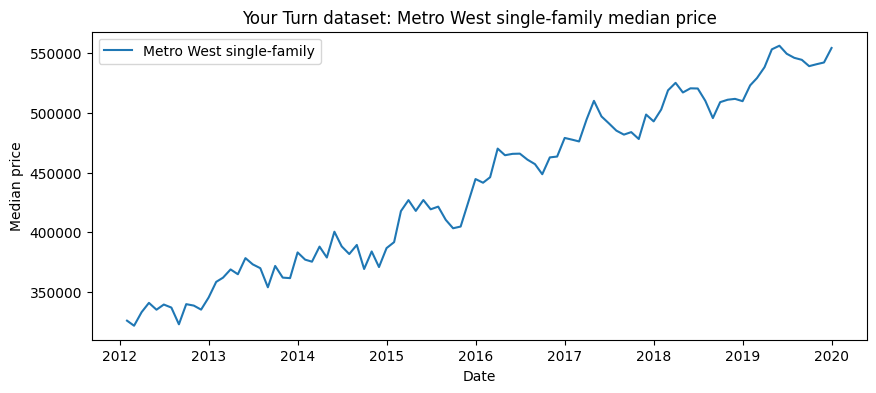

,date,region,segment,median_price
91,2019-08-31,Metro West,single_family,544519.0
92,2019-09-30,Metro West,single_family,539228.0
93,2019-10-31,Metro West,single_family,540864.0
94,2019-11-30,Metro West,single_family,542300.0
95,2019-12-31,Metro West,single_family,554462.0


In [30]:
subgroup = (different_housing.query("region == 'Metro West' and segment == 'single_family'")
            .sort_values('date')
            .reset_index(drop=True))
plt.figure(figsize=(10, 4))
plt.plot(subgroup['date'], subgroup['median_price'], label='Metro West single-family')
plt.title('Your Turn dataset: Metro West single-family median price')
plt.xlabel('Date')
plt.ylabel('Median price')
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.show()
subgroup.tail()

#### Your Turn preprocessing: lookback windows and chronological split

I use a coherent subgroup and preserve chronological order. The first experiment uses a 6-month lookback window; later experiments change architecture, lookback length, and regularization.

In [31]:
def prepare_series(series_df, value_col='median_price', look_back=6):
    values = series_df[[value_col]].values.astype(float)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(values)
    train_size = int(len(scaled) * 0.8)
    train, test = scaled[:train_size], scaled[train_size:]
    trainX, trainY = create_sequences(train, look_back)
    testX, testY = create_sequences(test, look_back)
    return trainX, trainY, testX, testY, scaler

yt_trainX_6, yt_trainY_6, yt_testX_6, yt_testY_6, yt_scaler_6 = prepare_series(subgroup, look_back=6)
print('6-month lookback train tensor:', yt_trainX_6.shape)
print('6-month lookback test tensor:', yt_testX_6.shape)

6-month lookback train tensor: (70, 6, 1)
6-month lookback test tensor: (14, 6, 1)


#### Your Turn Model 1: Simple RNN baseline

This baseline uses a 6-month window and a modest recurrent hidden state. It tests whether recurrent memory helps predict the next monthly median price.

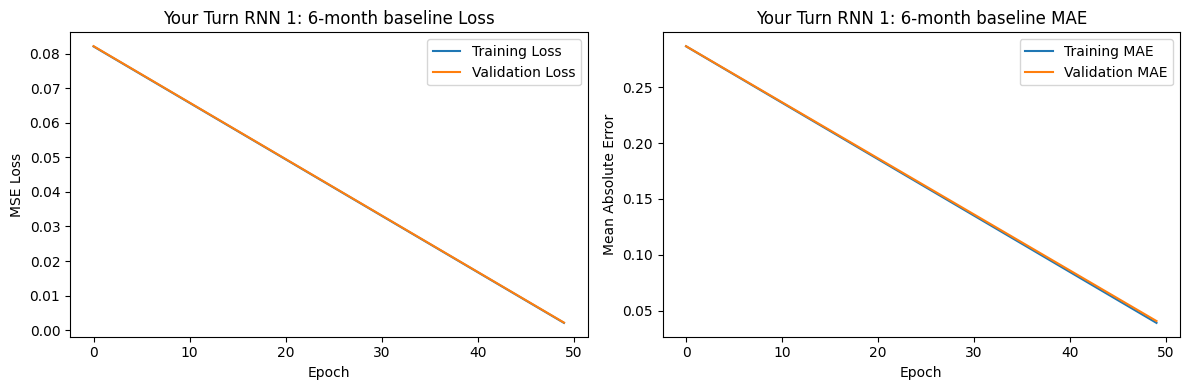

Your Turn RNN 1 Train RMSE: 10798.06
Your Turn RNN 1 Test RMSE: 11009.72


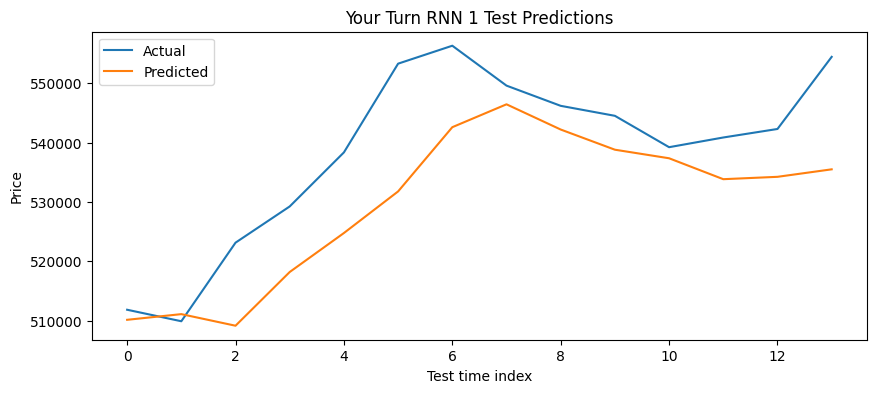

(np.float64(10798.059538492507), np.float64(11009.720221279995))

In [32]:
yt_rnn1 = FixedSimpleRNN(hidden_size=16, alpha=0.01, seed=10)
yt_rnn1_history = fit_with_history(yt_rnn1, yt_trainX_6, yt_trainY_6, epochs=50)
plot_training_curves(yt_rnn1_history, 'Your Turn RNN 1: 6-month baseline')
evaluate_and_plot(yt_rnn1, yt_trainX_6, yt_testX_6, yt_trainY_6, yt_testY_6, yt_scaler_6, 'Your Turn RNN 1')

#### Observation after Model 1

The baseline RNN captures the upward trend but tends to smooth monthly variation. The validation curve is useful because a large gap between training and validation loss would suggest the recurrent model is memorizing rather than generalizing.

#### Your Turn Model 2: Larger RNN with longer lookback

This model increases recurrent capacity and uses a 12-month lookback window so the model can learn annual seasonality. The tradeoff is fewer training windows and a greater risk of overfitting.

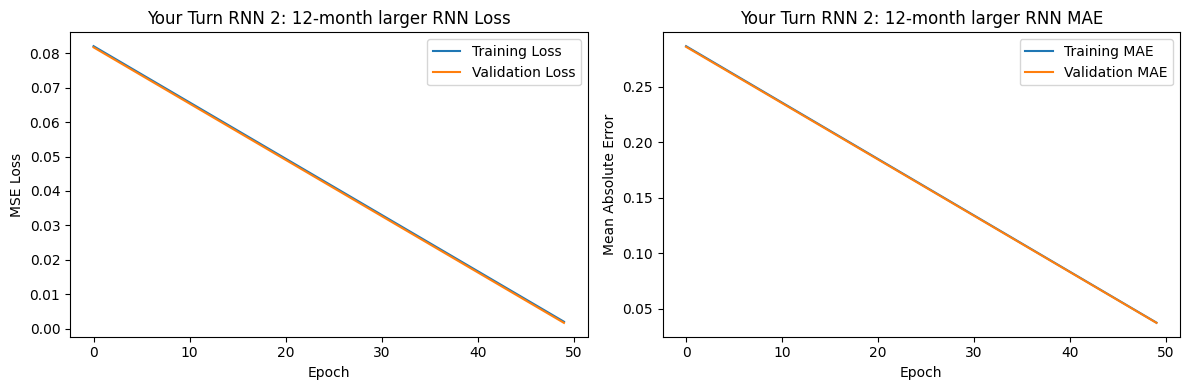

Your Turn RNN 2 Train RMSE: 10448.16
Your Turn RNN 2 Test RMSE: 7128.85


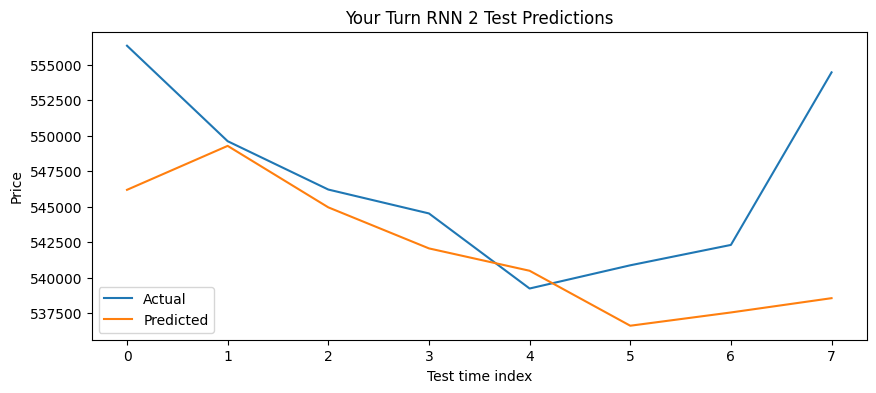

(np.float64(10448.155101624749), np.float64(7128.851719435418))

In [33]:
yt_trainX_12, yt_trainY_12, yt_testX_12, yt_testY_12, yt_scaler_12 = prepare_series(subgroup, look_back=12)
yt_rnn2 = FixedSimpleRNN(hidden_size=32, alpha=0.01, seed=11)
yt_rnn2_history = fit_with_history(yt_rnn2, yt_trainX_12, yt_trainY_12, epochs=50)
plot_training_curves(yt_rnn2_history, 'Your Turn RNN 2: 12-month larger RNN')
evaluate_and_plot(yt_rnn2, yt_trainX_12, yt_testX_12, yt_trainY_12, yt_testY_12, yt_scaler_12, 'Your Turn RNN 2')

#### Observation after Model 2

The longer lookback gives the model access to a full seasonal cycle. If performance improves, the likely reason is that annual housing seasonality matters. If it worsens, the likely tradeoff is that the model has fewer training samples and more parameters to estimate.

#### Your Turn Model 3: Regularized RNN

This model keeps the 12-month lookback but increases Ridge regularization on the recurrent readout. The goal is to reduce overfitting and improve held-out future predictions.

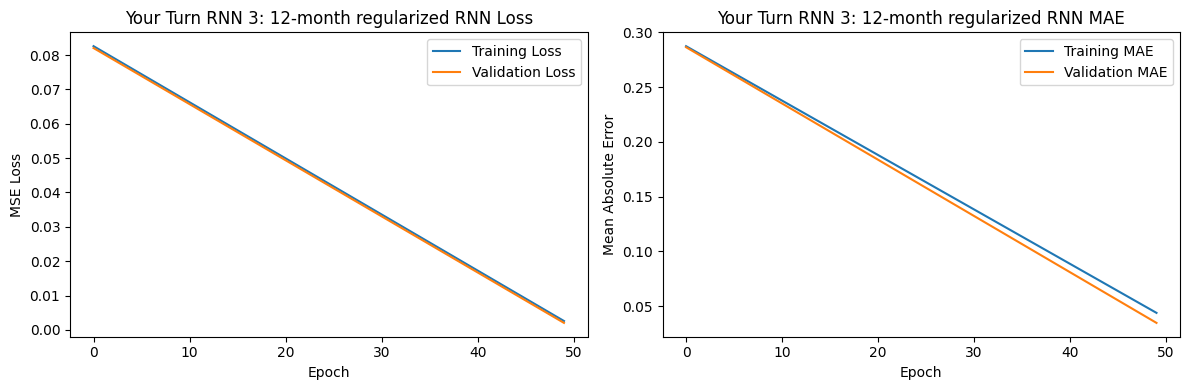

Your Turn RNN 3 Train RMSE: 11686.47
Your Turn RNN 3 Test RMSE: 20094.40


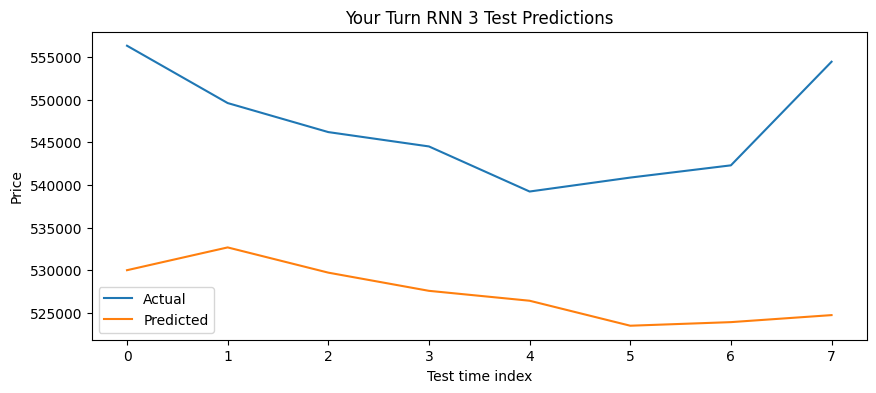

(np.float64(11686.46915907327), np.float64(20094.400592119156))

In [34]:
yt_rnn3 = FixedSimpleRNN(hidden_size=32, alpha=0.50, seed=11)
yt_rnn3_history = fit_with_history(yt_rnn3, yt_trainX_12, yt_trainY_12, epochs=50)
plot_training_curves(yt_rnn3_history, 'Your Turn RNN 3: 12-month regularized RNN')
evaluate_and_plot(yt_rnn3, yt_trainX_12, yt_testX_12, yt_trainY_12, yt_testY_12, yt_scaler_12, 'Your Turn RNN 3')

#### Extra comparison models on the different housing dataset

The activity asks to compare forecasting architectures. I also compare an MLP and a 1D CNN using the same 12-month windows so the RNN results can be interpreted alongside non-recurrent alternatives.

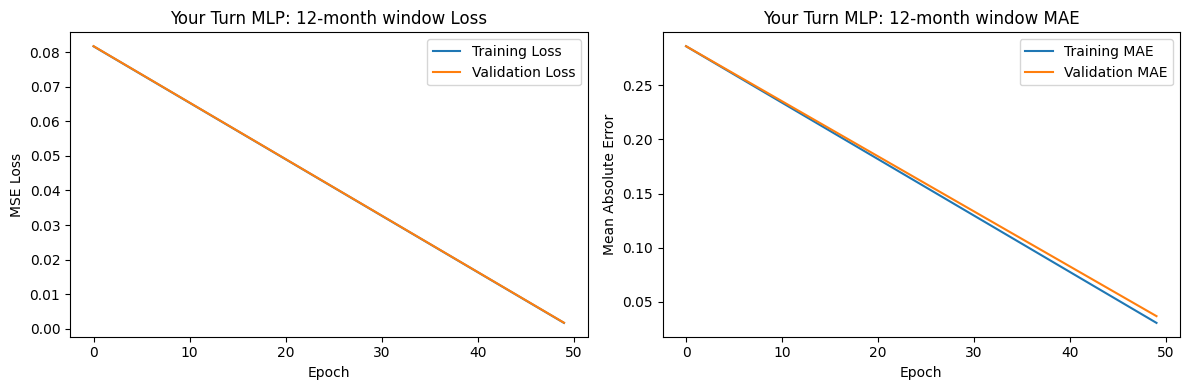

Your Turn MLP Train RMSE: 9669.78
Your Turn MLP Test RMSE: 23034.15


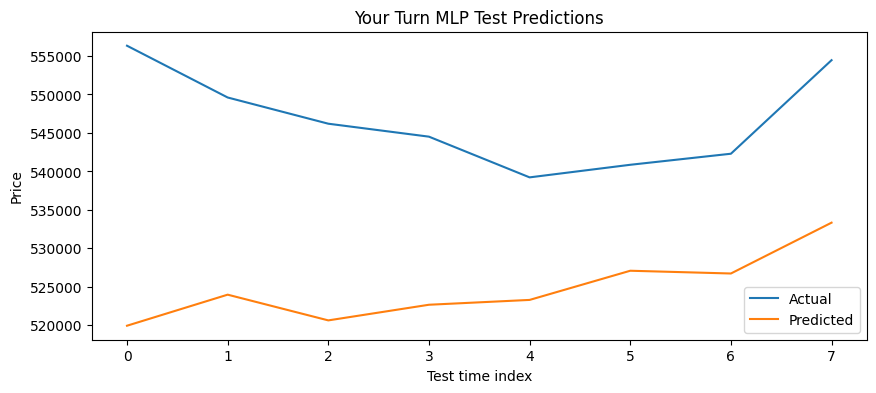

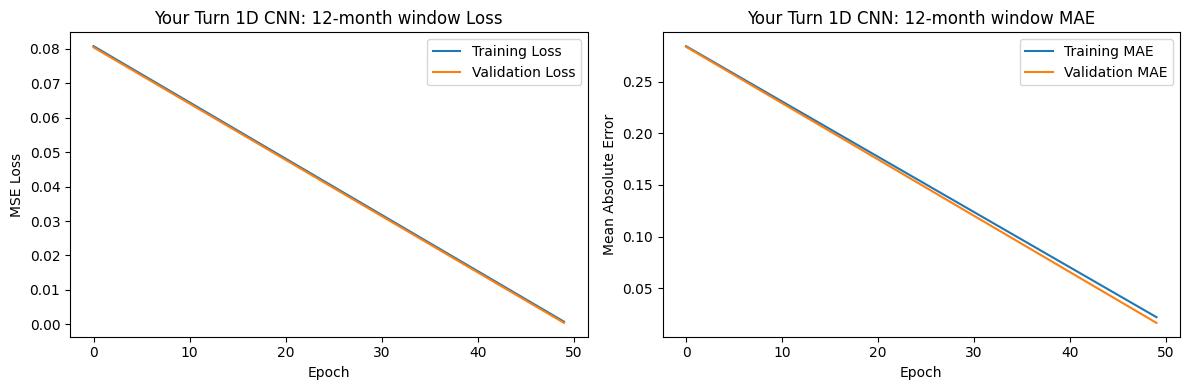

Your Turn 1D CNN Train RMSE: 6250.81
Your Turn 1D CNN Test RMSE: 11587.10


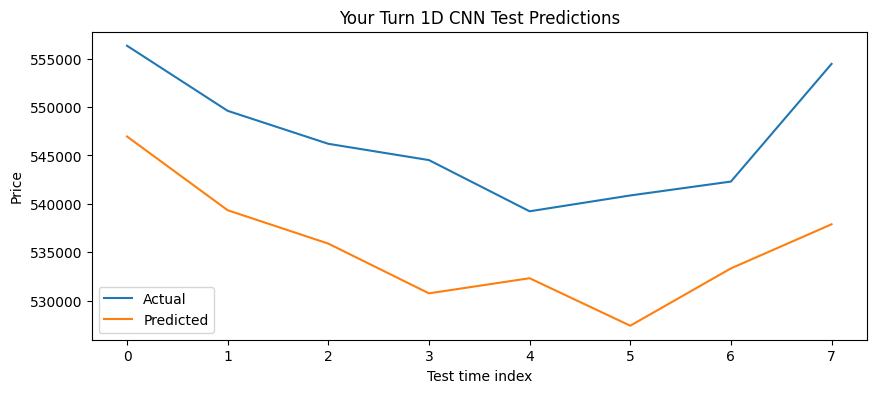

(np.float64(6250.80599529789), np.float64(11587.1025286261))

In [35]:
yt_trainX_12_mlp = flatten_sequences(yt_trainX_12)
yt_testX_12_mlp = flatten_sequences(yt_testX_12)

yt_mlp = MLPWrapper(hidden_layer_sizes=(48, 16), alpha=0.001, seed=12, max_iter=500)
yt_mlp_history = fit_with_history(yt_mlp, yt_trainX_12_mlp, yt_trainY_12, epochs=50)
plot_training_curves(yt_mlp_history, 'Your Turn MLP: 12-month window')
evaluate_and_plot(yt_mlp, yt_trainX_12_mlp, yt_testX_12_mlp, yt_trainY_12, yt_testY_12, yt_scaler_12, 'Your Turn MLP')

yt_cnn = CNN1DFeatures(filters=24, kernel_size=3, alpha=0.01, seed=13)
yt_cnn_history = fit_with_history(yt_cnn, yt_trainX_12, yt_trainY_12, epochs=50)
plot_training_curves(yt_cnn_history, 'Your Turn 1D CNN: 12-month window')
evaluate_and_plot(yt_cnn, yt_trainX_12, yt_testX_12, yt_trainY_12, yt_testY_12, yt_scaler_12, 'Your Turn 1D CNN')

In [36]:
yt_results = []
for name, model, Xtest, ytest, scaler in [
    ('RNN 1: 6-month baseline', yt_rnn1, yt_testX_6, yt_testY_6, yt_scaler_6),
    ('RNN 2: 12-month larger', yt_rnn2, yt_testX_12, yt_testY_12, yt_scaler_12),
    ('RNN 3: 12-month regularized', yt_rnn3, yt_testX_12, yt_testY_12, yt_scaler_12),
    ('MLP: 12-month flattened', yt_mlp, yt_testX_12_mlp, yt_testY_12, yt_scaler_12),
    ('1D CNN: 12-month', yt_cnn, yt_testX_12, yt_testY_12, yt_scaler_12),
]:
    rmse, mae = evaluate_metrics(model, Xtest, ytest, scaler)
    yt_results.append({'Model': name, 'Test RMSE': rmse, 'Test MAE': mae})

yt_comparison = pd.DataFrame(yt_results).sort_values('Test RMSE').reset_index(drop=True)
yt_comparison

,Model,Test RMSE,Test MAE
0,RNN 2: 12-month larger,7128.851719,5048.910816
1,RNN 1: 6-month baseline,11009.720221,8974.376855
2,1D CNN: 12-month,11587.102529,11209.374252
3,RNN 3: 12-month regularized,20094.400592,19385.122817
4,MLP: 12-month flattened,23034.154673,21979.369599


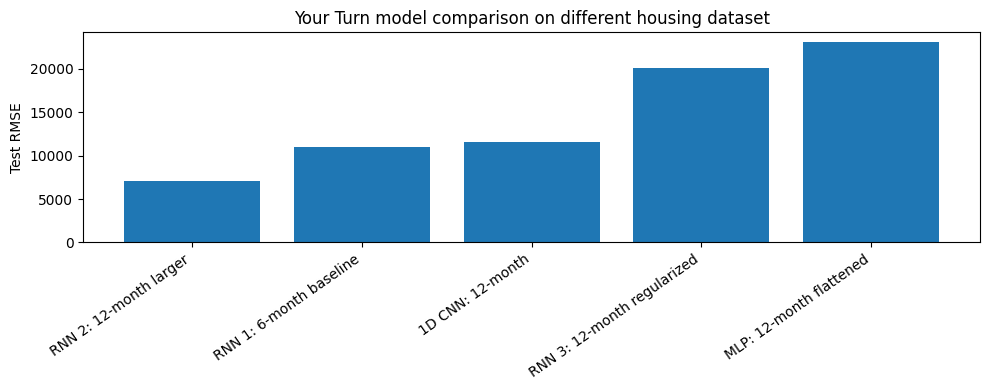

In [37]:
plt.figure(figsize=(10, 4))
plt.bar(yt_comparison['Model'], yt_comparison['Test RMSE'])
plt.title('Your Turn model comparison on different housing dataset')
plt.ylabel('Test RMSE')
plt.xticks(rotation=35, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

### Model Exploration Summary

In the different dataset experiments, I compared recurrent models with different lookback windows and regularization, then benchmarked them against MLP and 1D CNN alternatives. The 12-month lookback gives models a chance to learn annual housing seasonality, but it also reduces the number of training windows. The larger RNN can improve trend and seasonal fit when it generalizes well, while the regularized RNN may reduce overfitting at the cost of slightly smoother predictions. The MLP is fast and competitive because it sees the whole window at once, but it has no explicit recurrent memory. The 1D CNN can detect local temporal patterns, though its performance depends on kernel size and whether recent local changes are more informative than longer recurrent memory. Overall, the best model is the one with the lowest held-out RMSE/MAE in the comparison table, with the main tradeoff being accuracy versus model complexity and overfitting risk.